In [ ]:
import os
import pandas as pd
import numpy as np
from concurrent import futures
#sklearn
from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingClassifier,  GradientBoostingClassifier
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, balanced_accuracy_score, f1_score, roc_auc_score, precision_score, recall_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from hiclass import LocalClassifierPerNode, LocalClassifierPerParentNode, LocalClassifierPerLevel

from patchOTDA.utils import EXAMPLE_DATA_, REF_DATA_, VISp_MET_nodes, VISp_T_nodes, \
    filter_MMS, find_outlier_idxs, param_grid_from_dict, select_by_col, not_select_by_col,\
CLASS_MODELS, HICLASS_METHOD, MMS_DATA

from patchOTDA.external import skada
from patchOTDA.domainAdapt import PatchClampOTDA
from functools import partial

import matplotlib.pyplot as plt
import joblib
%matplotlib inline

# --- Reproducibility & hyperparameter constants ---
RANDOM_STATE = 42
KNN_K = 5           # neighbors for KNNImputer
N_ITER = 100        # nevergrad tuning budget
N_JOBS = 5          # parallel workers for tuning
np.random.seed(RANDOM_STATE)

labels="VISp_T"
hiclass_method = "LocalClassifierPerNode"
class_model = "GradientBoostingClassifier"

2026-03-23 12:36:48.543 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [2]:
#load in the CKTE_M1 and VISp_view datasets
ref_data = MMS_DATA['VISp_Viewer']
ref_data_ephys, ref_data_meta = ref_data['ephys'], ref_data['meta']
Xs, Ys = ref_data_ephys, ref_data_meta[[labels+"_1_en", labels+"_2_en", labels+"_3_en"]]

data = MMS_DATA['CTKE_M1']
data_ephys, data_meta = data['ephys'], data['meta']
data_ephys = data_ephys.loc[data_meta.index]
data_meta = data_meta.loc[data_ephys.index]
Xt, Yt = data_ephys, data_meta[[labels+"_1_en", labels+"_2_en", labels+"_3_en"]]

## Phase 1: Data Exploration & QC
Inspect class distributions at each hierarchical level for both source (VISp_Viewer) and target (CTKE_M1).  
**Important:** Label encoders are fit per-dataset independently we re-encode jointly to ensure compatible integer codes.

  Level 1 (Broad class): classes ONLY in target (cannot be predicted by source-trained model): {'L6b', 'L2/3', 'Microglia', 'L6IT', 'L5PT', 'L5NP', 'L5IT', 'L4IT', 'L6CT'}
  Level 2 (Subtype): classes ONLY in target (cannot be predicted by source-trained model): {'L4IT_IT', 'L5NP_NP', 'L5PT_PT', 'L6CT_CT', 'L2/3_IT', 'L5IT_IT', 'L6b_P2ry12', 'L6IT_IT', 'L6b_ALM', 'L6b_VISp', 'Microglia_Siglech', 'L6b_Hsd17b2'}
  Level 3 (Fine-grained): classes ONLY in source (cannot be evaluated on target): {'Vip_Igfbp6_Pltp'}
  Level 3 (Fine-grained): classes ONLY in target (cannot be predicted by source-trained model): {'L5IT_IT_VISp', 'L4IT_IT_VISp', 'L6b_ALM_Olfr111', 'L2/3_IT_VISp', 'L5NP_NP_ALM', 'L5PT_PT_ALM', 'L6CT_CT_ALM', 'L6b_VISp_Mup5', 'L5IT_IT_ALM', 'L6b_VISp_Crh', 'Microglia_Siglech', 'L2/3_IT_ALM', 'L6IT_IT_ALM', 'L6b_VISp_Col8a1', 'L5NP_NP_VISp', 'L6b_P2ry12', 'L5PT_PT_VISp', 'L6IT_IT_VISp', 'L6b_Hsd17b2', 'L6CT_CT_VISp'}


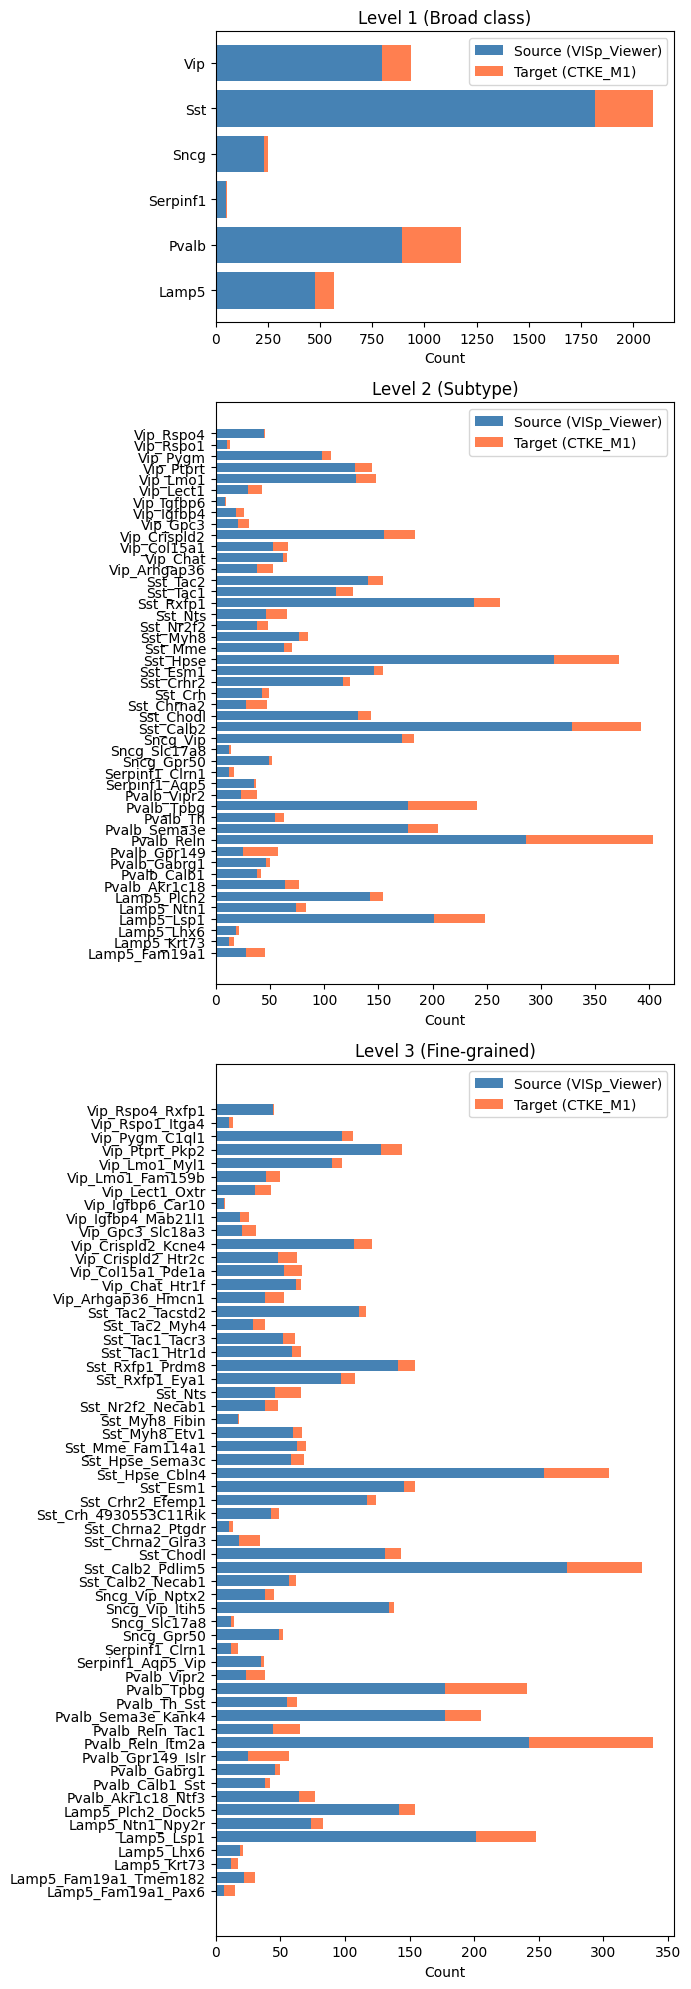

In [ ]:
# --- Step 1: Joint label encoding & class distribution QC ---
# The per-dataset LabelEncoders may assign different integers to the same class name.
# We build joint encoders so source and target labels are directly comparable.

joint_le = {}  # {level: LabelEncoder}
Ys_arr = Ys.to_numpy()
Yt_arr = Yt.to_numpy()

for lvl in range(3):
    le_s = MMS_DATA['VISp_Viewer'][f'{labels}_LE_{lvl+1}']
    le_t = MMS_DATA['CTKE_M1'][f'{labels}_LE_{lvl+1}']
    # Decode both to strings
    Ys_str = le_s.inverse_transform(Ys_arr[:, lvl].astype(int))
    Yt_str = le_t.inverse_transform(Yt_arr[:, lvl].astype(int))
    # Fit a joint encoder on the union of class names
    all_classes = np.union1d(np.unique(Ys_str), np.unique(Yt_str))
    le_joint = LabelEncoder()
    le_joint.fit(all_classes)
    joint_le[lvl] = le_joint
    # Re-encode with joint encoder
    Ys_arr[:, lvl] = le_joint.transform(Ys_str)
    Yt_arr[:, lvl] = le_joint.transform(Yt_str)

# --- Class distribution & filtering ---
level_names = ['Level 1 (Broad class)', 'Level 2 (Subtype)', 'Level 3 (Fine-grained)']

# Report classes unique to one dataset
for lvl in range(3):
    s_classes = set(joint_le[lvl].inverse_transform(np.unique(Ys_arr[:, lvl].astype(int))))
    t_classes = set(joint_le[lvl].inverse_transform(np.unique(Yt_arr[:, lvl].astype(int))))
    only_source = s_classes - t_classes
    only_target = t_classes - s_classes
    if only_source:
        print(f"  {level_names[lvl]}: classes ONLY in source (cannot be evaluated on target): {only_source}")
    if only_target:
        print(f"  {level_names[lvl]}: classes ONLY in target (cannot be predicted by source-trained model): {only_target}")

# Filter to common classes — compute masks per level INDEPENDENTLY on the
# original arrays, then intersect, so no level's filtering compounds onto another.
s_keep = np.ones(len(Ys_arr), dtype=bool)
t_keep = np.ones(len(Yt_arr), dtype=bool)

for lvl in range(3):
    le_j = joint_le[lvl]
    s_classes = set(le_j.inverse_transform(np.unique(Ys_arr[:, lvl].astype(int))))
    t_classes = set(le_j.inverse_transform(np.unique(Yt_arr[:, lvl].astype(int))))
    common_classes = s_classes.intersection(t_classes)
    common_codes = le_j.transform(list(common_classes))
    s_keep &= np.isin(Ys_arr[:, lvl].astype(int), common_codes)
    t_keep &= np.isin(Yt_arr[:, lvl].astype(int), common_codes)

# Apply combined mask once
Xs = Xs[s_keep]
Xt = Xt[t_keep]
Ys = Ys[s_keep]
Yt = Yt[t_keep]
Ys_arr = Ys_arr[s_keep]
Yt_arr = Yt_arr[t_keep]

print(f"\nAfter filtering: Source {Ys_arr.shape[0]} samples, Target {Yt_arr.shape[0]} samples")

# --- Class distribution plots (post-filter) ---
fig, axes = plt.subplots(3, 1, figsize=(7, 20), height_ratios=[1,2,3])

for lvl in range(3):
    le_j = joint_le[lvl]
    ax = axes[lvl]
    s_codes, s_counts = np.unique(Ys_arr[:, lvl].astype(int), return_counts=True)
    t_codes, t_counts = np.unique(Yt_arr[:, lvl].astype(int), return_counts=True)

    all_codes = np.union1d(s_codes, t_codes)
    class_names = le_j.inverse_transform(all_codes)
    s_count_map = dict(zip(s_codes, s_counts))
    t_count_map = dict(zip(t_codes, t_counts))
    s_vals = np.array([s_count_map.get(c, 0) for c in all_codes])
    t_vals = np.array([t_count_map.get(c, 0) for c in all_codes])

    y_pos = np.arange(len(class_names))
    ax.barh(y_pos, s_vals, color='steelblue', label='Source (VISp_Viewer)')
    ax.barh(y_pos, t_vals, left=s_vals, color='coral', label='Target (CTKE_M1)')
    ax.set_yticks(y_pos)
    ax.set_yticklabels(class_names)
    ax.set_title(level_names[lvl])
    ax.set_xlabel('Count')
    ax.legend()

fig.tight_layout()
plt.show()

In [4]:
#check the feature columns of the two datasets, and find the common features
print("VISp_Viewer features:", Xs.columns)
print("CTKE_M1 features:", Xt.columns)
common_features = Xs.columns.intersection(Xt.columns)
print("Common features:", common_features)

VISp_Viewer features: Index(['AP amplitude (mV)', 'AP threshold (mV)', 'AP width (ms)',
       'Adaptation ratio', 'After hyperpolarization (mV)', 'Avg ISI',
       'F I curve slope', 'Fast trough V (long square) (millivolts)',
       'Fast trough V (ramp) (millivolts)',
       'Fast trough V (short square) (millivolts)', 'Input resistance (MΩ)',
       'Peak V (long square) (millivolts)', 'Peak V (ramp) (millivolts)',
       'Peak V (short square) (millivolts)', 'Rebound APs (number)',
       'Resting membrane potential (mV)', 'Sag ratio',
       'Threshold I (long square) (picoamps)', 'Threshold I (ramp) (picoamps)',
       'Threshold I (short square) (picoamps)',
       'Threshold V (long square) (millivolts)',
       'Threshold V (ramp) (millivolts)',
       'Threshold V (short square) (millivolts)',
       'Trough V (long square) (millivolts)', 'Trough V (ramp) (millivolts)',
       'Trough V (short square) (millivolts)',
       'Upstroke/downstroke ratio (long square)',
       'U

In [ ]:
# Preprocess: common features, imputation, scaling
# NOTE: Imputer and scaler are fit on the CONCATENATION of source + target so that
# both domains share the same feature statistics. This is standard for unsupervised
# domain adaptation where we have access to unlabeled target features at training time.
Xs_common = Xs[common_features]
Xt_common = Xt[common_features]

X_all = pd.concat([Xs_common, Xt_common], axis=0)

impute_and_scale_pipeline = Pipeline([
    ('imputer', KNNImputer(n_neighbors=KNN_K)),
    ('scaler', StandardScaler())
])
X_all_processed = impute_and_scale_pipeline.fit_transform(X_all)
Xs_preprocessed = X_all_processed[:len(Xs_common)]
Xt_preprocessed = X_all_processed[len(Xs_common):]

# Sanity check: feature matrices and label arrays must have matching row counts
assert Xs_preprocessed.shape[0] == Ys_arr.shape[0], f"Source mismatch: X={Xs_preprocessed.shape[0]}, Y={Ys_arr.shape[0]}"
assert Xt_preprocessed.shape[0] == Yt_arr.shape[0], f"Target mismatch: X={Xt_preprocessed.shape[0]}, Y={Yt_arr.shape[0]}"
print(f"Source: {Xs_preprocessed.shape[0]} samples, Target: {Xt_preprocessed.shape[0]} samples — shapes OK")

In [ ]:
# OT tuning — set seed for nevergrad reproducibility
np.random.seed(RANDOM_STATE)
da_flex = PatchClampOTDA(flexible_transporter=False)
da_flex.tune(Xs_preprocessed, Xt_preprocessed, n_iter=N_ITER, n_jobs=N_JOBS, method='unidirectional', verbose=True)

Xs_flex = da_flex.fit_transform(Xs_preprocessed, Xt_preprocessed)

INFO:root:Setting verbosity to INFO
INFO:patchOTDA.domainAdapt:Using default error function for unsupervised learning
/home/smestern/miniconda3/envs/patchotda/lib/python3.11/site-packages/ot/lp/_network_simplex.py:332: UserWarning: numItermax reached before optimality. Try to increase numItermax.
  result_code_string = check_result(result_code)
/home/smestern/miniconda3/envs/patchotda/lib/python3.11/site-packages/ot/lp/_network_simplex.py:332: UserWarning: numItermax reached before optimality. Try to increase numItermax.
  result_code_string = check_result(result_code)
/home/smestern/miniconda3/envs/patchotda/lib/python3.11/site-packages/ot/lp/_network_simplex.py:332: UserWarning: numItermax reached before optimality. Try to increase numItermax.
  result_code_string = check_result(result_code)
/home/smestern/miniconda3/envs/patchotda/lib/python3.11/site-packages/ot/lp/_network_simplex.py:332: UserWarning: numItermax reached before optimality. Try to increase numItermax.
  result_code_s

## Feature Distribution: Before vs After Domain Adaptation
PCA projections showing source/target overlap before and after OT transport.  
Points colored by Level 1 label (excitatory / inhibitory).

IndexError: boolean index did not match indexed array along dimension 0; dimension is 4258 but corresponding boolean dimension is 4260

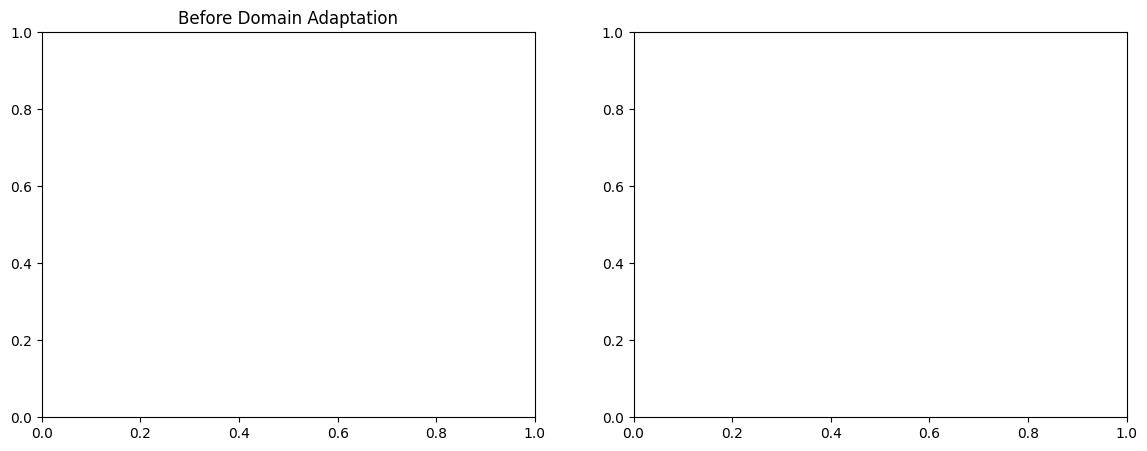

In [ ]:
# --- Step 2: PCA visualization — before vs after DA ---
# PCA is fit ONCE on the pre-DA data so both panels share the same coordinate system.
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=RANDOM_STATE)

# Level-1 string labels for coloring (use joint encoder on filtered arrays)
Ys_l1_str = joint_le[0].inverse_transform(Ys_arr[:, 0].astype(int))
Yt_l1_str = joint_le[0].inverse_transform(Yt_arr[:, 0].astype(int))
unique_classes = np.unique(np.concatenate([Ys_l1_str, Yt_l1_str]))
cmap = {c: plt.cm.tab10(i) for i, c in enumerate(unique_classes)}

# Fit PCA on pre-DA data (shared basis for both panels)
X_both_before = np.vstack([Xs_preprocessed, Xt_preprocessed])
pca.fit(X_both_before)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# BEFORE DA
pc_before = pca.transform(X_both_before)
pc_s_before = pc_before[:len(Xs_preprocessed)]
pc_t_before = pc_before[len(Xs_preprocessed):]

ax = axes[0]
ax.set_title('Before Domain Adaptation')
for cls in unique_classes:
    mask_s = Ys_l1_str == cls
    mask_t = Yt_l1_str == cls
    ax.scatter(pc_s_before[mask_s, 0], pc_s_before[mask_s, 1],
               c=[cmap[cls]], marker='o', alpha=0.4, label=f'Src: {cls}', s=15)
    ax.scatter(pc_t_before[mask_t, 0], pc_t_before[mask_t, 1],
               c=[cmap[cls]], marker='x', alpha=0.4, label=f'Tgt: {cls}', s=15)
ax.legend(fontsize=7, loc='best')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')

# AFTER DA — same PCA basis, only source changes
pc_s_after = pca.transform(Xs_flex)
pc_t_after = pca.transform(Xt_preprocessed)

ax = axes[1]
ax.set_title('After Domain Adaptation (OT)')
for cls in unique_classes:
    mask_s = Ys_l1_str == cls
    mask_t = Yt_l1_str == cls
    ax.scatter(pc_s_after[mask_s, 0], pc_s_after[mask_s, 1],
               c=[cmap[cls]], marker='o', alpha=0.4, label=f'Src: {cls}', s=15)
    ax.scatter(pc_t_after[mask_t, 0], pc_t_after[mask_t, 1],
               c=[cmap[cls]], marker='x', alpha=0.4, label=f'Tgt: {cls}', s=15)
ax.legend(fontsize=7, loc='best')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')

fig.tight_layout()
plt.show()

## Phase 2: Baseline — No Domain Adaptation
Train a hierarchical classifier (`LocalClassifierPerNode` with `GradientBoostingClassifier`) on the **raw** preprocessed source data and predict on the target.  
This establishes how well a classifier transfers *without* distribution alignment.

In [ ]:
# --- Step 3: Baseline hierarchical classifier (no DA) ---
import logging as _logging

def safe_inverse_transform(le, codes):
    """Decode integer codes; warn and label any code outside the encoder's known set."""
    lookup = {i: name for i, name in enumerate(le.classes_)}
    result = []
    unknown_codes = set()
    for c in codes:
        if c in lookup:
            result.append(lookup[c])
        else:
            unknown_codes.add(c)
            result.append(f"Unknown({c})")
    if unknown_codes:
        _logging.warning(f"Predicted codes not in encoder: {unknown_codes}")
    return np.array(result)

baseline_clf = LocalClassifierPerNode(
    local_classifier=GradientBoostingClassifier(random_state=RANDOM_STATE),
)
baseline_clf.fit(Xs_preprocessed, Ys_arr)
Yt_pred_baseline = baseline_clf.predict(Xt_preprocessed)

print("Baseline predictions shape:", Yt_pred_baseline.shape)
print("Sample predictions (first 5):")
for lvl in range(3):
    decoded = safe_inverse_transform(joint_le[lvl], Yt_pred_baseline[:5, lvl].astype(int))
    print(f"  Level {lvl+1}: {decoded}")

ValueError: Found input variables with inconsistent numbers of samples: [4260, 4258]

In [ ]:
# --- Step 4: Evaluate baseline ---
def evaluate_per_level(y_true, y_pred, joint_le, label=""):
    """Compute per-level metrics and return a summary DataFrame."""
    rows = []
    for lvl in range(y_true.shape[1]):
        yt = y_true[:, lvl].astype(int)
        yp = y_pred[:, lvl].astype(int)
        n = len(yt)
        n_classes = len(np.unique(yt))
        rows.append({
            'Level': f'Level {lvl+1}',
            'N': n,
            'Classes': n_classes,
            'Accuracy': accuracy_score(yt, yp),
            'Balanced Accuracy': balanced_accuracy_score(yt, yp),
            'F1 (macro)': f1_score(yt, yp, average='macro', zero_division=0),
        })
    df = pd.DataFrame(rows).set_index('Level')
    df.columns.name = label
    return df

baseline_results = evaluate_per_level(Yt_arr, Yt_pred_baseline, joint_le, label="Baseline (No DA)")
print("=== Baseline Results (No Domain Adaptation) ===")
display(baseline_results)

## Phase 3: DA + Hierarchical Classification
Train the same hierarchical classifier on the **OT-transported** source data (`Xs_flex`) and predict on the target.  
The transported source distribution should be closer to the target, improving cross-dataset generalization.

In [ ]:
# --- Step 5: DA-corrected hierarchical classifier ---
da_clf = LocalClassifierPerNode(
    local_classifier=GradientBoostingClassifier(random_state=RANDOM_STATE),
)
da_clf.fit(Xs_flex, Ys_arr)  # Train on OT-transported source
Yt_pred_da = da_clf.predict(Xt_preprocessed)  # Predict on raw target

print("DA predictions shape:", Yt_pred_da.shape)
print("Sample predictions (first 5):")
for lvl in range(3):
    decoded = safe_inverse_transform(joint_le[lvl], Yt_pred_da[:5, lvl].astype(int))
    print(f"  Level {lvl+1}: {decoded}")

In [ ]:
# --- Step 6: Evaluate DA classifier ---
da_results = evaluate_per_level(Yt_arr, Yt_pred_da, joint_le, label="DA (OT)")
print("=== DA Results (OT Domain Adaptation) ===")
display(da_results)

## Phase 4: Comparative Analysis
Side-by-side metrics table and confusion matrix grid comparing Baseline vs DA at each hierarchical level.

In [ ]:
# --- Step 7: Comparative summary table ---
comparison = baseline_results.join(da_results, lsuffix=' (Baseline)', rsuffix=' (DA)')

# Compute deltas
delta_cols = []
for metric in ['Accuracy', 'Balanced Accuracy', 'F1 (macro)']:
    col = f'Δ {metric}'
    comparison[col] = comparison[f'{metric} (DA)'] - comparison[f'{metric} (Baseline)']
    delta_cols.append(col)

# Dynamic color scale based on actual delta range
delta_abs_max = max(comparison[delta_cols].abs().max().max(), 0.01)

print("=== Baseline vs Domain Adaptation — Side-by-Side ===")
display(comparison.style.format("{:.3f}").background_gradient(
    subset=delta_cols,
    cmap='RdYlGn', vmin=-delta_abs_max, vmax=delta_abs_max
))

In [ ]:
# --- Step 8: Confusion matrix grid (2×3) ---
level_names = ['Level 1 (Broad class)', 'Level 2 (Subtype)', 'Level 3 (Fine-grained)']

fig, axes = plt.subplots(2, 3, figsize=(20, 10))

for row, (y_pred, method_name) in enumerate([(Yt_pred_baseline, 'Baseline'), (Yt_pred_da, 'DA (OT)')]):
    for lvl in range(3):
        ax = axes[row, lvl]
        yt = Yt_arr[:, lvl].astype(int)
        yp = y_pred[:, lvl].astype(int)

        # Use only codes known to the joint encoder for labeling
        all_labels = np.union1d(yt, yp)
        known_labels = np.array([c for c in all_labels if c < len(joint_le[lvl].classes_)])
        class_names = joint_le[lvl].inverse_transform(known_labels)

        # Mask to known labels for consistent accuracy & confusion matrix
        known_mask = np.isin(yt, known_labels) & np.isin(yp, known_labels)
        cm = confusion_matrix(yt[known_mask], yp[known_mask], labels=known_labels, normalize='true')
        im = ax.imshow(cm, interpolation='nearest', cmap='Blues', vmin=0, vmax=1)
        ax.set_xticks(range(len(class_names)))
        ax.set_yticks(range(len(class_names)))
        ax.set_xticklabels(class_names, rotation=45, ha='right', fontsize=7)
        ax.set_yticklabels(class_names, fontsize=7)

        acc = accuracy_score(yt[known_mask], yp[known_mask])
        ax.set_title(f'{method_name} — {level_names[lvl]}\nAcc: {acc:.3f} (N={known_mask.sum()})', fontsize=10)
        ax.set_ylabel('True') if lvl == 0 else None
        ax.set_xlabel('Predicted')

fig.colorbar(im, ax=axes, shrink=0.6, label='Recall (row-normalized)')
fig.tight_layout()
plt.show()